In [10]:
from matplotlib import pyplot as plt
import numpy as np

import torch
from torch import Tensor
dtype = torch.float32
torch.set_default_dtype(dtype)
device = 'cpu'
torch.set_default_device(device)

from GPNeuron import DGP, GaussianLikelihood, Model

In [11]:
def toy_func(x: Tensor) -> tuple[Tensor, Tensor]:
    mean = x.mul(4).mul(torch.pi).cos().mul(x).mul(x.sigmoid())
    std = x.mul(1).mul(torch.pi).cos().square().mul(0.1).add(x.square().neg().add(1).mul(0.1))
    return mean, std

In [12]:
num_point = 256
x_grid = torch.arange(num_point).mul((num_point - 1) ** -1).mul(2).sub(1).unsqueeze(1)

In [13]:
f_mean_grid, f_std_grid = toy_func(x_grid)

In [14]:
sample_size = 1024
x = torch.tensor(np.random.RandomState(0).rand(sample_size, 1), dtype=dtype).mul(2).sub(1).mul(1.1)
f_mean, f_std = toy_func(x)
z = torch.tensor(np.random.RandomState(0).randn(sample_size, 1), dtype=dtype)
y = f_std.mul(z).add(f_mean)

In [15]:
network = DGP((1, 1, 1), 64)
network.init_induc_loc(x)
likelihood = GaussianLikelihood(1)
model = Model(network, likelihood)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
print('num_param =', sum(p.numel() for p in model.parameters()))
model

num_param = 267


Model(
  (network): DGP(
    dims=(1, 1, 1)
    nums_induc=(64, 64)
    (layers): ModuleList(
      (0-1): 2 x SGP(
        dim=1, size=(1,), num_induc=64
        (mean): AffineMean(dim=1, size=(1,))
        (kernel): KernelND(dim=1, size=(1,))
      )
    )
  )
  (likelihood): GaussianLikelihood(dim=1)
)

In [16]:
num_step = 50000
for _ in range(num_step):
    optimizer.zero_grad()
    loss = model.penalized_loglikelihood(x, y, sample_size).neg()
    loss.backward()
    optimizer.step()

In [17]:
with torch.no_grad():
    pred_mean, pred_var = network(x_grid)
    pred_var = pred_var.add(likelihood.obs_noise)
pred_std = pred_var.sqrt()

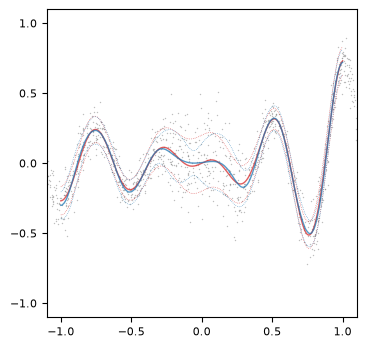

In [18]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.tick_params(axis='both', which='major', labelsize=8)
ax.set_xticks(np.linspace(-1, 1, 5))
ax.set_yticks(np.linspace(-1, 1, 5))
ax.plot(x_grid, f_mean_grid, lw=1, c='tab:red', alpha=0.75)
ax.plot(x_grid, f_mean_grid.sub(f_std_grid), ls='dotted', lw=0.5, c='tab:red', alpha=0.75)
ax.plot(x_grid, f_mean_grid.add(f_std_grid), ls='dotted', lw=0.5, c='tab:red', alpha=0.75)
ax.scatter(x, y, s=1, lw=0, c='tab:gray', alpha=0.5)
ax.plot(x_grid, pred_mean, lw=1, c='tab:blue', alpha=0.75)
ax.plot(x_grid, pred_mean.sub(pred_std), ls='dotted', lw=0.5, c='tab:blue', alpha=0.75)
ax.plot(x_grid, pred_mean.add(pred_std), ls='dotted', lw=0.5, c='tab:blue', alpha=0.75)
fig.savefig('./toy1d.pdf', bbox_inches='tight', pad_inches=0.1)
plt.show()